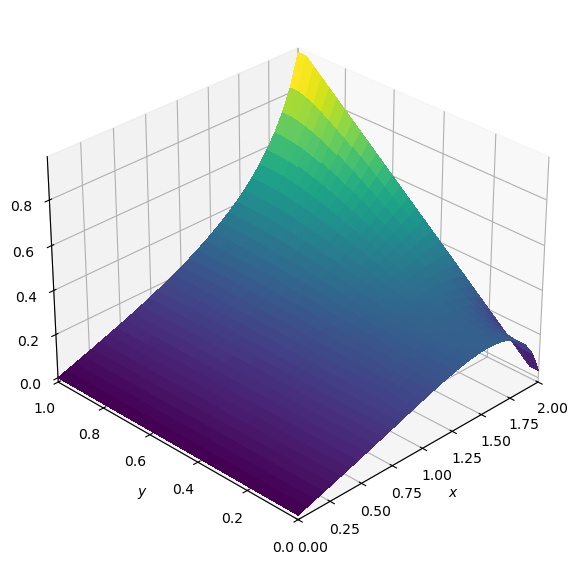

In [18]:
# 	2D Laplace Equation
import numpy
from matplotlib import pyplot, cm
from mpl_toolkits.mplot3d import Axes3D

def plot2D(x, y, p):
    fig = pyplot.figure(figsize=(11, 7), dpi=100)
    ax = fig.add_subplot(projection='3d')
    X, Y = numpy.meshgrid(x, y)
    ax.plot_surface(X, Y, p, cmap=cm.viridis, linewidth=0, antialiased=False) # 绘制3D曲面：X/Y网格，p是高度，viridis配色，无线条、关闭抗锯齿
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 1)
    ax.view_init(30, 225) # 设置3D图视角：仰角30°，方位角225°（最佳观察角度）
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')

def laplace2d(p, y, dx, dy, l1norm_target):
    l1norm = 1 # 初始化收敛误差为1
    pn = numpy.empty_like(p)

    while l1norm > l1norm_target:
        pn = p.copy()
        p[1:-1, 1:-1] = ((dy**2 * (pn[1:-1, 2:] + pn[1:-1, 0:-2]) + 
                          dx**2 * (pn[2:, 1:-1] + pn[0:-2, 1:-1])) /
                          (2 * (dx**2 + dy**2)))

        p[:, 0] = 0
        p[:, -1] = y
        p[0, :] = p[1, :]   # 上边界：梯度为0（绝热/无通量）
        p[-1, :] = p[-2, :] # 下边界：梯度为0（绝热/无通量）
        l1norm = (numpy.sum(numpy.abs(p[:]) - numpy.abs(pn[:])) /    # 计算L1范数：迭代误差（判断是否收敛）
                 numpy.sum(numpy.abs(pn[:])))             # l1norm = numpy.sum(numpy.abs(p - pn)) / numpy.sum(numpy.abs(pn))
 
    return p

nx = 31
ny = 31
c = 1
dx = 2 / (nx -1)
dy = 1 / (ny -1)

p = numpy.zeros((ny, nx))

x = numpy.linspace(0, 2, nx)
y = numpy.linspace(0, 1, ny)

p[:, 0] = 0
p[:, -1] = y
p[0, :] = p[1, :]
p[-1, :] = p[-2, :]

p = laplace2d(p, y, dx, dy, 1e-4)
plot2D(x, y, p)